# Modelagem Relacional (RelBench) - Previsão de Leitos

Este notebook serve como o _entry-point_ e teste para as classes que declaramos na camada de inteligência: `CNESDataset` e `PredictBedsTask`.
No processamento de aprendizado de grafos relacionais (Relational Deep Learning),
transformamos as bases relacionais fragmentadas pela métrica do tempo num fluxo natural para redes GNN (como PyTorch Geometric).

In [9]:
import sys
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from src.dataset import CNESDataset
from src.task import PredictBedsTask

import pyarrow.compute as pc
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### 1. Build & Load do Banco de Dados no Memória Gráfica (Dataset)
Chamamos a criação do database que agregará todos os Parquets da camada _03_primary/_ configurando-os com chaves primárias e estrangeiras.

In [10]:
dataset = CNESDataset(cache_dir="./cache/cnes_dataset")
print(f"Construindo grafo relacional usando os paths {BASE_DIR}/data/03_primary...")
db = dataset.make_db(municipio_id="355030")

print("Tabelas Carregadas no Grafo:")
print(list(db.table_dict.keys()))

Construindo grafo relacional usando os paths /home/phprestes/Documents/IC/data/03_primary...
[Grafo Raiz] tbEstabelecimento ancorada para 355030! Nós criados: 134766
[Subgrafo] rlEstabComplementar otimizada na leitura. Arestas capturadas: 10761
[Subgrafo] rlEstabComissaoOutro otimizada na leitura. Arestas capturadas: 22237
[Subgrafo] rlEstabUnidAcolhim otimizada na leitura. Arestas capturadas: 78
[Subgrafo] rlMunUnidAcolhim otimizada na leitura. Arestas capturadas: 7
[Subgrafo] rlEstabEqpUnidApoio otimizada na leitura. Arestas capturadas: 0
[Subgrafo] tbResidenciaMed otimizada na leitura. Arestas capturadas: 291
[Subgrafo] tbProfResidencia otimizada na leitura. Arestas capturadas: 2873
[Subgrafo] rlEstabServicoApoio otimizada na leitura. Arestas capturadas: 150449
[Subgrafo] tbEstabAtivSecundaria otimizada na leitura. Arestas capturadas: 95482
[Subgrafo] rlEstabRegimeRes otimizada na leitura. Arestas capturadas: 0
[Subgrafo] rlEstabInstFisiAssist otimizada na leitura. Arestas capturada

### 1.1. Dashboard Visual (São Paulo)
Rápida inspeção e estatísticas das propriedades dos hospitais do município de São Paulo.

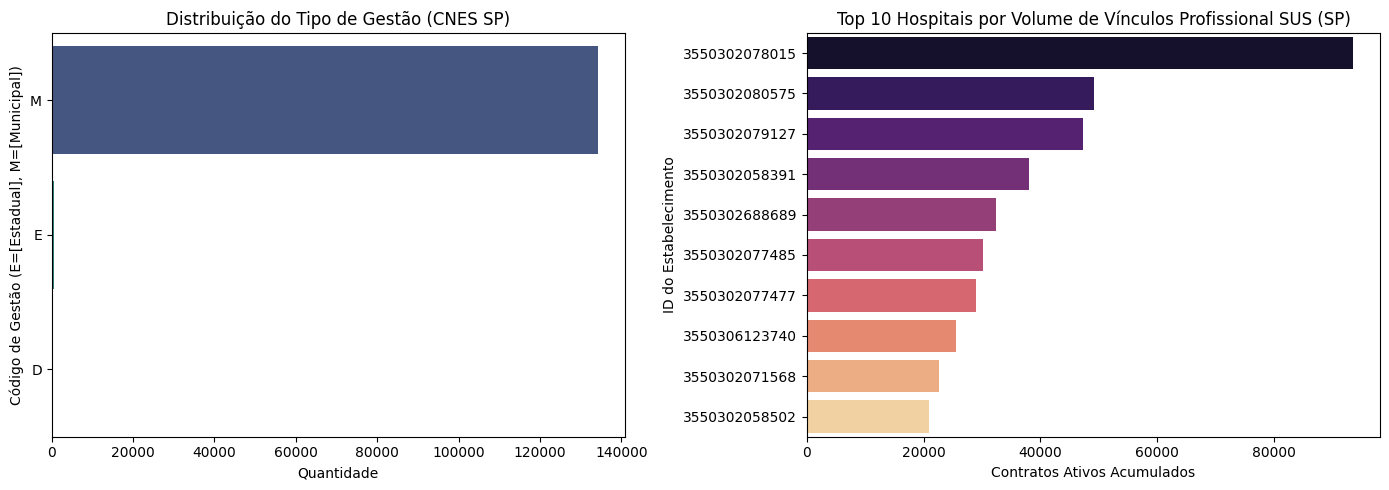

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# sp_estab foi internalizado dentro do make_db() filtrando direto no pyarrow
sp_estab = db.table_dict["tbEstabelecimento"].df
df_viz = sp_estab.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(y="tp_gestao", data=df_viz, ax=axes[0], palette="viridis", hue="tp_gestao", legend=False)
axes[0].set_title("Distribuição do Tipo de Gestão (CNES SP)")
axes[0].set_ylabel("Código de Gestão (E=[Estadual], M=[Municipal])")
axes[0].set_xlabel("Quantidade")

# Agregação paralela: Volume de vínculos profissionais
sus_df = db.table_dict["tbCargaHorariaSus"].df.select(["co_unidade"]).to_pandas()
sp_sus = sus_df[sus_df["co_unidade"].isin(df_viz["co_unidade"])]
top_10 = sp_sus["co_unidade"].value_counts().head(10)

sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette="magma", hue=top_10.index, legend=False)
axes[1].set_title("Top 10 Hospitais por Volume de Vínculos Profissional SUS (SP)")
axes[1].set_ylabel("ID do Estabelecimento")
axes[1].set_xlabel("Contratos Ativos Acumulados")

plt.tight_layout()
plt.show()


### 2. Definição do Escopo do Task (Previsão de Leitos)
O alvo é testar se nosso `make_table` extrai os `targets` perfeitamente em uma janela de avaliação (timestamps de 2021 e 2023).

In [12]:
task = PredictBedsTask(dataset=dataset)

# Avaliando a tabela de tarefas produzida pela task para o ano de Teste (Val/Test)
task_table = task.make_table(db, [dataset.val_timestamp, dataset.test_timestamp])

task_table.head(10)

,co_unidade,qt_exist,timestamp
0,3550300075426,27,2023-01-01
1,3550300102105,527,2023-01-01
2,3550300158100,70,2023-01-01
3,3550300161438,216,2023-01-01
4,3550300263192,171,2023-01-01
5,3550300393290,76,2023-01-01
6,3550300466573,6,2023-01-01
7,3550300469734,11,2023-01-01
8,3550300507733,14,2023-01-01
9,3550300663913,40,2023-01-01


A partir desta `task_table` (contendo Entidade, Tempo e Target), a abstração do Relbench permite usar `relbench.modeling.GraphDataset(db, task_table)` e serializar num Frame para uso de Modelos LightGBM de baseline, ou exportar as tensores num DataLoader de Graph Neural Network!

### 3. Setup de Treinamento GNN e Feature Engineering Automático

Abaixo consolidamos automaticamente as features numéricas e categóricas (com Imputação, Normalização e Ordinal Enconding) usando a abstração criada. Em seguida aplicamos um loop Full-Batch pela `DynamicHeteroGNN` recém consolidada no arquivo base.

In [49]:
import torch
import torch.nn.functional as F
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
import torch_geometric.transforms as T
from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
from src.model import DynamicHeteroGNN, train, test

# ==============================================================================
# 1. INGESTÃO E GERAÇÃO DAS LABELS TEMPORAIS (FORÇANDO O FILTRO ESPACIAL)
# ==============================================================================
print("1. Carregando Banco de Dados APENAS para São Paulo (355030)...")
data = HeteroData()

# CORREÇÃO: Apenas um timestamp por fase para evitar colisão de nós (nós duplicados)
train_timestamps = [pd.Timestamp('2021-01-01')]
val_timestamps = [pd.Timestamp('2023-01-01')]
test_timestamps = [pd.Timestamp('2025-01-01')] 

print("Gerando Tabelas da Task restritas ao subgrafo...")
# Utilizamos 'make_table' passando o 'db' já filtrado para evitar o OOM no Relbench
train_table = task.make_table(db, train_timestamps)
val_table = task.make_table(db, val_timestamps)
test_table = task.make_table(db, test_timestamps)

# ==============================================================================
# 2. FEATURE ENGINEERING AUTOMÁTICO DA RAIZ
# ==============================================================================
def process_table_features(df_input, pkey, fkeys_dict):
    df = df_input.to_pandas() if hasattr(df_input, 'to_pandas') else df_input.copy()
    
    ignore_cols = [pkey, "to_chardt_atualizacaoddmmyyyy"] + list(fkeys_dict.keys())
    ignore_cols = [c for c in ignore_cols if c is not None]
    feature_cols = [c for c in df.columns if c not in ignore_cols]
    
    if not feature_cols or len(df) == 0:
        return torch.ones((len(df), 1), dtype=torch.float32), df
        
    df_features = df[feature_cols].copy()
    num_cols = df_features.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df_features.select_dtypes(include=['object', 'category']).columns.tolist()
    
    tensor_list = []
    if num_cols:
        num_data = SimpleImputer(strategy='constant', fill_value=0).fit_transform(df_features[num_cols])
        # StandardScaler atua APENAS nos valores que são de fato contínuos/numéricos
        num_data = StandardScaler().fit_transform(num_data)
        tensor_list.append(torch.tensor(num_data, dtype=torch.float32))
        
    if cat_cols:
        df_features[cat_cols] = df_features[cat_cols].fillna('Desconhecido').astype(str)
        cat_data = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(df_features[cat_cols])
        tensor_list.append(torch.tensor(cat_data, dtype=torch.float32))
        
    if not tensor_list:
        return torch.ones((len(df), 1), dtype=torch.float32), df
    
    # RETORNO CORRETO: Junta as listas sem aplicar normalizações que destroem as categorias
    return torch.cat(tensor_list, dim=1), df

print("Vetorizando tbEstabelecimento (Nó Raiz)...")
x_estab, estab_df = process_table_features(
    db.table_dict["tbEstabelecimento"].df, 
    db.table_dict["tbEstabelecimento"].pkey_col, 
    db.table_dict["tbEstabelecimento"].fkey_col_to_pkey_table
)
estab_df['node_id'] = range(len(estab_df))
estab_map = estab_df.set_index("co_unidade")['node_id'].to_dict()

data["tbEstabelecimento"].x = x_estab

# ==============================================================================
# 2. CONSTRUÇÃO DINÂMICA DAS ARESTAS (COM EARLY PRUNING)
# ==============================================================================
print("2. Construindo Topologia do Grafo (Nós Periféricos e Arestas)...")

# Cache das chaves válidas para busca rápida
valid_unidades_set = set(estab_map.keys())

for table_name, table_obj in db.table_dict.items():
    if table_name == "tbEstabelecimento":
        continue 
        
    if "co_unidade" in table_obj.fkey_col_to_pkey_table:
        
        # 1. Extração segura para o Pandas
        raw_df = table_obj.df.to_pandas() if hasattr(table_obj.df, 'to_pandas') else table_obj.df
        
        # 2. EARLY PRUNING: Cortamos as linhas indesejadas ANTES de extrair features!
        # Isso salva gigabytes de RAM.
        valid_mask = raw_df["co_unidade"].isin(valid_unidades_set)
        child_df_filtered = raw_df[valid_mask].copy()
        
        if len(child_df_filtered) == 0:
            continue # Se a tabela não tem dados para São Paulo, ignoramos.
            
        # 3. Scikit-Learn pesado atua APENAS nos milhares de registros de SP (Rápido e Leve)
        x_child, child_df_valid = process_table_features(
            child_df_filtered, 
            table_obj.pkey_col, 
            table_obj.fkey_col_to_pkey_table
        )

        data[table_name].x = x_child
        
        # 4. Construção dos Tensores de Aresta
        child_df_valid = child_df_valid.reset_index(drop=True)
        num_nodos_filhos = len(child_df_valid)
        
        edge_target = torch.tensor(child_df_valid["co_unidade"].map(estab_map).values, dtype=torch.long)
        edge_source = torch.arange(num_nodos_filhos, dtype=torch.long)
        
        # DECLARAÇÃO EXPLÍCITA PARA SILENCIAR O AVISO
        data[table_name].num_nodes = num_nodos_filhos
        
        # Adiciona a aresta no formato (Origem, Relacionamento, Destino)
        data[table_name, f"pertence_{table_name}", "tbEstabelecimento"].edge_index = torch.stack([edge_source, edge_target])

# Torna o grafo inteiro bidirecional
data = T.ToUndirected()(data)
print(f"Grafo Heterogêneo Construído com sucesso!\n")

# ==============================================================================
# 4. PREPARAÇÃO DOS ALVOS NATIVOS DO RELBENCH E DATALOADERS
# ==============================================================================
def prep_relbench_input(table, estab_map):
    """Converte a Tabela do Relbench para os tensores de entrada do PyG"""
    valid_df = table[table["co_unidade"].isin(estab_map.keys())]
    node_indices = torch.tensor([estab_map[co] for co in valid_df["co_unidade"]], dtype=torch.long)
    targets = torch.tensor(valid_df["qt_exist"].values, dtype=torch.float32)
    return node_indices, targets

train_idx, train_y = prep_relbench_input(train_table, estab_map)
val_idx, val_y     = prep_relbench_input(val_table, estab_map)
test_idx, test_y   = prep_relbench_input(test_table, estab_map)

# CORREÇÃO: Criando tensores separados para Treino, Validação e Teste
y_train_full = torch.zeros(len(estab_df))
y_train_full[train_idx] = train_y
data["tbEstabelecimento"].y_train = y_train_full

y_val_full = torch.zeros(len(estab_df))
y_val_full[val_idx] = val_y
data["tbEstabelecimento"].y_val = y_val_full

y_test_full = torch.zeros(len(estab_df))
y_test_full[test_idx] = test_y
data["tbEstabelecimento"].y_test = y_test_full

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"3. Inicializando Treinamento (Mini-Batch) no dispositivo: {device}")

loader_kwargs = {
    "data": data,
    "num_neighbors": {key: [15, 10] for key in data.edge_types},
    "batch_size": 512,
    "num_workers": 4
}

train_loader = NeighborLoader(**loader_kwargs, input_nodes=("tbEstabelecimento", train_idx), shuffle=True)
val_loader   = NeighborLoader(**loader_kwargs, input_nodes=("tbEstabelecimento", val_idx), shuffle=False)
test_loader  = NeighborLoader(**loader_kwargs, input_nodes=("tbEstabelecimento", test_idx), shuffle=False)

# ==============================================================================
# 5. LOOP DE TREINAMENTO (COM FILTRO ESTRITO DE SUBGRAFOS)
# ==============================================================================
model = DynamicHeteroGNN(data.metadata(), hidden_channels=32, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

import copy
@torch.no_grad()
def evaluate_model(loader, target_col):
    model.eval()
    total_loss = 0
    total_nodes = 0
    
    for batch in loader:
        batch = batch.to(device)
        safe_x_dict = {nt: batch.x_dict[nt] if (nt in batch.x_dict and batch.x_dict[nt] is not None) else torch.empty((0, data[nt].x.shape[1] if 'x' in data[nt] else 1), dtype=torch.float32, device=device) for nt in data.metadata()[0]}
        safe_edge_index_dict = {et: batch.edge_index_dict[et] if (et in batch.edge_index_dict and batch.edge_index_dict[et] is not None) else torch.empty((2, 0), dtype=torch.long, device=device) for et in data.metadata()[1]}
        
        out = model(safe_x_dict, safe_edge_index_dict)
        batch_size = batch["tbEstabelecimento"].batch_size
        
        # PREVISÃO: Usamos ReLU no final para garantir que o modelo nunca preveja leitos negativos
        pred = F.relu(out["tbEstabelecimento"][:batch_size].squeeze())
        target = batch["tbEstabelecimento"][target_col][:batch_size]
        
        # Avaliamos sempre com MSE para ser comparável com o Relbench RMSE
        loss = F.mse_loss(pred, target)
        total_loss += float(loss) * batch_size
        total_nodes += batch_size
        
    return (total_loss / total_nodes) ** 0.5 if total_nodes > 0 else float('inf')


print("\nIniciando Otimização Logarítmica...")

best_val_rmse = float('inf')
best_model_weights = None

for epoch in range(1, 31): 
    model.train()
    total_train_loss = 0
    total_train_nodes = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        safe_x_dict = {nt: batch.x_dict[nt] if (nt in batch.x_dict and batch.x_dict[nt] is not None) else torch.empty((0, data[nt].x.shape[1] if 'x' in data[nt] else 1), dtype=torch.float32, device=device) for nt in data.metadata()[0]}
        safe_edge_index_dict = {et: batch.edge_index_dict[et] if (et in batch.edge_index_dict and batch.edge_index_dict[et] is not None) else torch.empty((2, 0), dtype=torch.long, device=device) for et in data.metadata()[1]}
        
        out = model(safe_x_dict, safe_edge_index_dict)
        batch_size = batch["tbEstabelecimento"].batch_size
        
        pred = F.relu(out["tbEstabelecimento"][:batch_size].squeeze())
        target = batch["tbEstabelecimento"].y_train[:batch_size]
        
        # A VOLTA DA LÓGICA: Treinando em MSE (L2) para vencer na prova de RMSE (L2)
        loss = F.mse_loss(pred, target)
        loss.backward()
        
        # Mantemos o CLIP DE GRADIENTE para garantir que não vai explodir
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()
        
        # Métrica de exibição no console
        with torch.no_grad():
            mse_real = F.mse_loss(pred, target)
            total_train_loss += float(mse_real) * batch_size
            total_train_nodes += batch_size
        
    train_rmse = (total_train_loss / total_train_nodes) ** 0.5
    val_rmse = evaluate_model(val_loader, "y_val")
    
    print(f"Época {epoch:02d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_model_weights = copy.deepcopy(model.state_dict())
        print("  -> Novo melhor modelo salvo!")

# ==============================================================================
# 6. O VEREDITO: TESTE DO MELHOR MODELO (DADOS DO FUTURO)
# ==============================================================================
print("\n" + "="*50)
print("🏆 AVALIAÇÃO FINAL DO MELHOR MODELO (CONJUNTO DE TESTE - 2025)")
print("="*50)

# Carregamos os pesos da "fotografia" do melhor momento do treinamento
model.load_state_dict(best_model_weights)

# Disparamos o modelo contra os dados que ele nunca viu
test_rmse = evaluate_model(test_loader, "y_test")

print(f">> A Rede Neural GNN previu a infraestrutura de leitos com um erro médio (RMSE) de: {test_rmse:.4f} leitos.")

1. Carregando Banco de Dados APENAS para São Paulo (355030)...
Gerando Tabelas da Task restritas ao subgrafo...
Vetorizando tbEstabelecimento (Nó Raiz)...
2. Construindo Topologia do Grafo (Nós Periféricos e Arestas)...
Grafo Heterogêneo Construído com sucesso!

3. Inicializando Treinamento (Mini-Batch) no dispositivo: cpu

Iniciando Otimização Logarítmica...
Época 01 | Train RMSE: 175.5443 | Val RMSE: 200.7680
  -> Novo melhor modelo salvo!
Época 02 | Train RMSE: 173.1883 | Val RMSE: 200.7181
  -> Novo melhor modelo salvo!
Época 03 | Train RMSE: 166.8248 | Val RMSE: 197.8752
  -> Novo melhor modelo salvo!
Época 04 | Train RMSE: 170.0112 | Val RMSE: 200.2308
Época 05 | Train RMSE: 165.3107 | Val RMSE: 194.7789
  -> Novo melhor modelo salvo!
Época 06 | Train RMSE: 163.5030 | Val RMSE: 197.0174
Época 07 | Train RMSE: 165.9871 | Val RMSE: 197.0403
Época 08 | Train RMSE: 166.4431 | Val RMSE: 194.8894
Época 09 | Train RMSE: 164.9852 | Val RMSE: 195.4569
Época 10 | Train RMSE: 164.8632 | Val

In [50]:
baseline_naive_rmse = F.mse_loss(
    data["tbEstabelecimento"].y_val[test_idx],
    data["tbEstabelecimento"].y_test[test_idx]
) ** 0.5

print(f"RMSE do Modelo Baseline (Persistência): {baseline_naive_rmse:.4f} leitos")
print(f"RMSE da Rede Neural (GNN): {test_rmse:.4f} leitos")

if test_rmse < baseline_naive_rmse:
    print("✅ VITÓRIA! A GNN previu o futuro melhor do que simplesmente assumir que nada mudaria no SUS.")
else:
    print("❌ ALERTA: A GNN não conseguiu superar o modelo ingênuo. Ela não capturou a dinâmica de evolução da rede.")

RMSE do Modelo Baseline (Persistência): 185.7441 leitos
RMSE da Rede Neural (GNN): 211.7292 leitos
❌ ALERTA: A GNN não conseguiu superar o modelo ingênuo. Ela não capturou a dinâmica de evolução da rede.
